In [1]:
import torch

from torchvision import transforms

from xaikd import attributors, models, datasets, utils, constants
from zennit.composites import EpsilonGammaBox, SpecialFirstLayerMapComposite, layer_map_base
from zennit.attribution import Gradient
from zennit.rules import Gamma, ZBox, BasicHook, zero_bias, GammaMod, NoMod
from zennit.types import Convolution

from torch.nn import functional as F
from matplotlib import pyplot as plt 

from PIL import Image

from tqdm import tqdm

import itertools

In [2]:
ds = datasets.construct("imagenet-butterfly")

ds_val = ds.create_subset(train_split=False)

ds_val.transform = lambda x: x

We have 300 images in classes [321, 322, 323, 324, 325, 326]


preparing `ImageNetButterfly` samples: 100%|█████████████████████████████████████████████████████████████████████████████████| 300/300 [00:00<00:00, 3137883.29it/s]


In [3]:
input_transform = ds.input_transformation

input_transform

ImageClassification(
    crop_size=[224]
    resize_size=[256]
    mean=[0.485, 0.456, 0.406]
    std=[0.229, 0.224, 0.225]
    interpolation=InterpolationMode.BILINEAR
)

In [4]:
rc_transform = transforms.Compose(
    [transforms.Resize(256), transforms.CenterCrop(224)]
)

In [5]:
IMAGE_LABEL_MAPPING = {
    "castle": 483
}
def load_image(name):
    image = Image.open(f"../../tests/data/{name}.jpg")
    return image, IMAGE_LABEL_MAPPING[name]

img, label = load_image("castle")

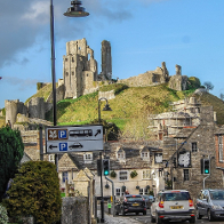

In [6]:
rc_transform(img)

In [7]:
from matplotlib.colors import ListedColormap
import numpy as np

def _heatmap(
    heatmap,
    title="",
    logit=None,
    reference_heatmap=None,
    total_score=None,
    fontsize=None,
):
    """Plot heatmap; this is adapted from https://git.tu-berlin.de/gmontavon/lrp-tutorial/-/blob/main/utils.py

    Args:
        heatmap np.array(h, w):
        reference_heatmap (np.array(h, w), optional): used for calculating normalization values. Defaults to None.
        total_score (float, optional): used for normalizing scores. Defaults to None.
    """
    assert len(heatmap.shape) == 2

    if reference_heatmap is None:
        reference_heatmap = heatmap

    assert len(reference_heatmap.shape) == 2

    b = np.abs(reference_heatmap).max()

    my_cmap = plt.cm.seismic(np.arange(plt.cm.seismic.N))
    my_cmap[:, 0:3] *= 0.85
    my_cmap = ListedColormap(my_cmap)

    sum_Ri = np.sum(heatmap)
    if total_score is None:
        percent = 100
        txt = r"$\sum_i R_i=%.2f$" % (sum_Ri)
    else:
        percent = (sum_Ri / total_score) * 100
        txt = r"$\sum_i R_i=%.4f$ (%3.1f%%)" % (sum_Ri, percent)

    plt.axis("on")
    plt.xticks([])
    plt.yticks([])
    plt.imshow(heatmap, cmap=my_cmap, vmin=-b, vmax=b)

    h = heatmap.shape[0]
    
    if logit is not None:
        plt.xlabel(f"{txt}, logit={logit:.4f}", fontsize=fontsize)
    else:
        plt.xlabel(f"{txt}", fontsize=fontsize)

In [8]:

        
class GammaGammaBox(SpecialFirstLayerMapComposite):
    def __init__(
        self,
        low,
        high,
        epsilon=1e-6,
        gamma=0.25,
        stabilizer=1e-6,
        layer_map=None,
        first_map=None,
        zero_params=None,
        canonizers=None
    ):
        if layer_map is None:
            layer_map = []
        if first_map is None:
            first_map = []

        rule_kwargs = {'zero_params': zero_params}
        layer_map = layer_map + layer_map_base(stabilizer) + [
            (Convolution, Gamma(gamma=gamma, stabilizer=stabilizer, **rule_kwargs)),
            (torch.nn.Linear, Gamma(gamma=gamma, stabilizer=stabilizer, **rule_kwargs)),
        ]
        first_map = first_map + [
            (Convolution, ZBox(low=low, high=high, stabilizer=stabilizer, **rule_kwargs))
        ]
        super().__init__(layer_map=layer_map, first_map=first_map, canonizers=canonizers)

In [10]:
def make_attributor_for(
    model,
    composite,
    input_statistics=[
        input_transform.mean,
        input_transform.std
    ],
    gamma=0.25,
    eps=1e-6,
):
    input_transform = transforms.Normalize(*input_statistics)

    low, high = input_transform(torch.tensor([[[[[0.0]]] * 3], [[[[1.0]]] * 3]]))

    canonizers = attributors.get_arch_specific_canonizer(model)

    if composite == "epsilongammabox":
        composite = EpsilonGammaBox(
            low=low, high=high, canonizers=canonizers,
            gamma=gamma,
            epsilon=eps,
        )
    elif composite == "gammagammabox":
        composite = GammaGammaBox(
            low=low, high=high, canonizers=canonizers,
            gamma=gamma,
            epsilon=eps,
            stabilizer=0
        )


    return Gradient(model=model, composite=composite)

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 6/6 [00:13<00:00,  2.26s/it]


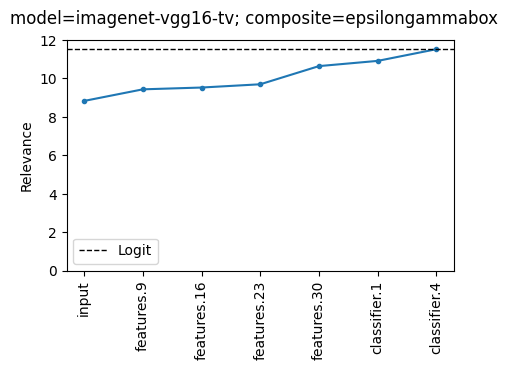

In [11]:
def viz(
    arch, arr_layers,
    composite="epsilongammabox"
):
        
    gamma = 0.25
    eps = 1e-6
    model = models.get_trained_model(arch)

    arr_rels = []
    

    inp = input_transform(img).unsqueeze(0)
    
    plt.figure(figsize=(5, 3))
    plt.suptitle(f"model={arch}; composite={composite}")
    for lix, layer in tqdm(list(enumerate(arr_layers))):
        
        module, hook = utils.interceptor.attach_hook_intercept_layer_output(
            model, layer, should_retain_grad=True
        )
            
        try:

            with make_attributor_for(model, composite=composite, gamma=gamma, eps=eps) as attributor:

                logits, attribution = attributor.forward(
                    inp, 
                    lambda logits: logits*F.one_hot(torch.Tensor([label]).long(), num_classes=1000)
                )
                
                logit = float(logits[0, label])
                
                if lix == 0:
                    arr_rels.append(float(attribution.sum()))
                
                act = utils.interceptor.get_output(module)
                rel = act.grad
                total_rel = float(rel.sum())
                arr_rels.append(total_rel)
        finally:
            hook.remove()
    arr_layers = ["input"] + arr_layers

    plt.ylabel("Relevance")
    plt.plot(arr_rels, marker=".")
    plt.axhline(logit, ls="--", lw=1, color="black", label="Logit")
    plt.xticks(range(len(arr_layers)), arr_layers, rotation=90)
    plt.legend()
    plt.ylim([0, logit+0.5])

viz(
    arch="imagenet-vgg16-tv",
    arr_layers=['features.9',  'features.16','features.23', 'features.30', 'classifier.1', 'classifier.4']
)

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 6/6 [00:13<00:00,  2.29s/it]


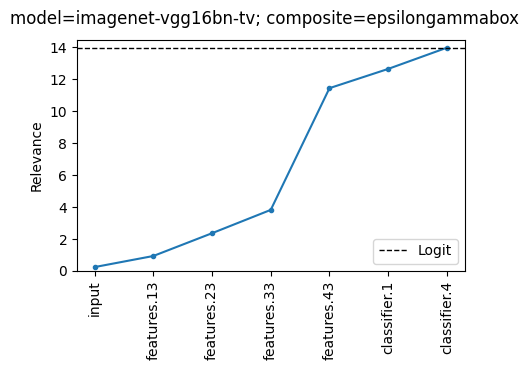

In [12]:
viz(
    arch="imagenet-vgg16bn-tv",
    arr_layers=['features.13',  'features.23','features.33', 'features.43', 'classifier.1', 'classifier.4']
)

In [ ]:
for arch, bn in tqdm(list(
    itertools.product(
        [
            "vgg11",
            "vgg13",
            "vgg16",
            "vgg19",
        ], 
        ["", "bn"]
    )
)):
    arr_layers = list(constants.ARCH_LAYER_DIMENSIONS[arch].keys()) + ["classifier.1", "classifier.4"]
        
    viz(
        arch=f"imagenet-{arch}{bn}-tv",
        arr_layers=arr_layers,
    )

In [ ]:
list(itertools.product(["vgg11", "vgg16"], ["", "bn"]))

In [ ]:
 list(constants.ARCH_LAYER_DIMENSIONS["vgg16"].keys())

In [ ]:
vggnn = models.get_trained_model("imagenet-vgg16bn-tv")

In [ ]:
vggnn

In [ ]:
cc = utils.modules.merge_conv_and_bn(
    vggnn.features[40],
    vggnn.features[41]
)

In [ ]:
vggnn.features[41].running_mean

In [ ]:
cc.bias

In [15]:
list(constants.ARCH_LAYER_DIMENSIONS.keys())

['resnet18',
 'resnet34',
 'resnet50',
 'resnet101',
 'resnet152',
 'vgg11',
 'vgg11bn',
 'vgg13',
 'vgg13bn',
 'vgg16',
 'vgg16bn',
 'vgg19',
 'vgg19bn']

In [17]:
for arch, bn in tqdm(list(
    itertools.product(
        [
            "vgg11",
            "vgg13",
            "vgg16",
            "vgg19",
        ], 
        ["", "bn"]
    )
)):
    print(f"imagenet-{arch}{bn}-tv")

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 8/8 [00:00<00:00, 114520.25it/s]

imagenet-vgg11-tv
imagenet-vgg11bn-tv
imagenet-vgg13-tv
imagenet-vgg13bn-tv
imagenet-vgg16-tv
imagenet-vgg16bn-tv
imagenet-vgg19-tv
imagenet-vgg19bn-tv


In [19]:
for arch, bn in tqdm(list(
    itertools.product(
        [
            "resnet18",
            "resnet34",
            "resnet101",
            "resnet152",
        ], 
        [""]
    )
)):
    print(f"imagenet-{arch}{bn}-tv")

100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 4/4 [00:00<00:00, 21290.88it/s]

imagenet-resnet18-tv
imagenet-resnet34-tv
imagenet-resnet101-tv
imagenet-resnet152-tv
